# PINN vs Chang-Cooper for GRB Synchrotron Emission

This notebook walks through, in order:

1. **The physical problem** we are modeling.
2. **The governing equation** and what each term means.
3. A **numerical solution** with Chang-Cooper, with plots.
4. **What the numerical solution teaches us** about the structure of $N(\gamma)$.
5. *Then* the ML part — log-coordinates, the equation rewritten, PINN losses, causality, sampling.
6. The PINN training and a side-by-side comparison.

---

## 1. The physical scenario

A gamma-ray burst (GRB) is the most luminous electromagnetic event in the universe — the
collapse of a massive star or the merger of two compact objects launches a relativistic
outflow at $\Gamma \sim 100$–$1000$. Inside that outflow, internal shocks accelerate
electrons into a non-thermal **power-law distribution**. The outflow drags along a tangled
magnetic field of order $B \sim 10^{4}\,$G. The accelerated electrons gyrate in the field
and emit **synchrotron** radiation — that is what we observe as the prompt $\gamma$-ray
spectrum.

The pipeline is:

$$\text{shock acceleration} \;\longrightarrow\; \text{electron distribution } N(\gamma, t) \;\longrightarrow\; \text{synchrotron emission} \;\longrightarrow\; \text{observed spectrum}.$$

The **goal of this notebook** is to solve for the middle quantity, $N(\gamma, t)$. Once we
have it, the spectrum is just a fast 1-D integral of the single-electron synchrotron
emissivity against $N$ — that part is easy and is not done here.

## 2. Variables and parameters

| Symbol | Meaning |
|--------|---------|
| $\gamma$ | Lorentz factor of an individual electron ($E = \gamma\, m_e c^2$). |
| $N(\gamma, t)\, d\gamma$ | Number of electrons with Lorentz factor in $[\gamma, \gamma + d\gamma]$ at time $t$. |
| $B$ | Magnetic-field strength in the emission region. |
| $p$ | Power-law index of the injection spectrum (from shock acceleration; observed values $\sim 2$–$3$). |
| $\gamma_{\min},\, \gamma_{\max}$ | Bounds of the injected electron population. |
| $T$ | Duration over which injection acts (the prompt phase). |
| $\gamma_{\rm cool}$ | Lorentz factor at which the cooling time equals $T$. **Emergent**, not free. |
| $C \equiv \sigma_T B^2 / (6\pi m_e c)$ | Synchrotron cooling coefficient. |

## 3. The governing equation

The electron population evolves under continuous injection from shocks and continuous
energy loss to synchrotron radiation. The kinetic (Fokker–Planck) equation is

$$\boxed{\;\;\frac{\partial N}{\partial t} \;+\; \frac{\partial}{\partial \gamma}\big(\dot\gamma\, N\big) \;=\; Q(\gamma)\;\;}$$

with

$$\dot\gamma \;=\; -C\gamma^{2}, \qquad Q(\gamma) \;=\; \gamma^{-p}\quad\text{for}\quad \gamma_{\min} \le \gamma \le \gamma_{\max}.$$

**Each term, physically:**

- $\dfrac{\partial N}{\partial t}$ — how the population at fixed $\gamma$ changes in time.
  If injection were off and there were no cooling, this would be zero and $N$ would be frozen.

- $\dfrac{\partial}{\partial \gamma}(\dot\gamma\, N)$ — **flux divergence in energy space**.
  Synchrotron cooling moves every electron toward lower $\gamma$ at a rate $\dot\gamma = -C\gamma^{2}$
  (faster for higher-energy electrons; this is the source of the equation's *stiffness*).
  Crucially, this term is in *divergence form*: electrons are not destroyed, they slide down
  in energy. **Electron number is conserved under cooling.**

- $Q(\gamma)$ — **source.** Internal shocks continuously inject fresh electrons with a
  power-law distribution between $\gamma_{\min}$ and $\gamma_{\max}$. Without $Q$, the
  population would simply drain to $\gamma = 0$.

**Burgess et al. (2020) modeling choices** (used throughout this notebook):

- **No escape term.** Some Fokker–Planck formulations include $-N/t_{\rm esc}$. Burgess does not —
  electrons remain in the emission region.
- **The cooling break $\gamma_{\rm cool}$ is emergent.** It comes from the **finite emission duration** $T$:
  $$\gamma_{\rm cool}(T) \;=\; \frac{1}{C\,T}.$$
  An electron injected at $t = 0$ has had the full duration $T$ to cool down to $\gamma_{\rm cool}$;
  an electron injected just before $t = T$ has barely cooled at all. This is why we integrate the
  *time-dependent* equation rather than reading off a steady-state expression.


In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import time
import sys
sys.path.insert(0, '.')

# FP64 everywhere -- MPS doesn't support it, so CPU
torch.set_default_dtype(torch.float64)
device = torch.device('cpu')
print(f'Device: {device}')
print(f'Default dtype: {torch.get_default_dtype()}')

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

Device: cpu
Default dtype: torch.float64


## Part 1: Ground Truth via Chang-Cooper (No Escape)

We solve the time-dependent Fokker-Planck equation **without escape**:

$$\frac{\partial N}{\partial t} + \frac{\partial}{\partial \gamma}(\dot{\gamma}\, N) = Q(\gamma)$$

Marginally fast cooling: $\chi = \gamma_{\text{cool}}/\gamma_{\min} = 0.8$

In [2]:
# Physical constants (CGS)
SIGMA_T  = 6.6524e-25
M_E      = 9.109e-28
C_LIGHT  = 2.998e10

# GRB parameters
B         = 1e4
p         = 2.5
gamma_min = 1e3
gamma_max = 1e6
gamma_cool = 8e2

# Derived
C_cool = SIGMA_T * B**2 / (6 * np.pi * M_E * C_LIGHT)
T_emission = 1.0 / (C_cool * gamma_cool)  # emission duration
chi = gamma_cool / gamma_min

print(f'C_cool = {C_cool:.4e} s^-1')
print(f'T_emission = {T_emission:.4e} s')
print(f'chi = {chi:.2f}  (marginally fast cooling)')
print(f'gamma_cool = 1/(C*T) = {1/(C_cool*T_emission):.0f}')
print(f'\nStiffness: t_cool(10)={1/(C_cool*10):.2e}s, t_cool(10^6)={1/(C_cool*1e6):.2e}s, ratio={1e6/10:.0e}')

C_cool = 1.2923e-01 s^-1
T_emission = 9.6724e-03 s
chi = 0.80  (marginally fast cooling)
gamma_cool = 1/(C*T) = 800

Stiffness: t_cool(10)=7.74e-01s, t_cool(10^6)=7.74e-06s, ratio=1e+05


In [3]:
from pychangcooper_fast.solver import (
    _build_log_grid, _compute_chang_cooper_weights,
    _build_tridiag_coefficients, _solve_full
)

# Integrate for exactly T_emission -- by construction, gamma_cool(T_emission) = 800
n_grid = 300; n_steps = 400
dt = T_emission / n_steps

grid, half_grid, delta_grid, delta_grid_bar, step = _build_log_grid(n_grid, gamma_max)
heating = -C_cool * half_grid**2
dispersion = np.zeros(n_grid - 1)
escape = np.zeros(n_grid)  # NO ESCAPE -- Burgess formulation

delta_j = _compute_chang_cooper_weights(half_grid, heating, dispersion, delta_grid, n_grid)
a, b, c = _build_tridiag_coefficients(n_grid, delta_j, delta_grid, delta_grid_bar,
                                        heating, dispersion, escape, dt)

# Injection source Q(gamma) = gamma^-p on [gamma_min, gamma_max]
# Normalize so that integral of Q*gamma (energy) = 1.
source = np.zeros(n_grid)
mask = (grid >= gamma_min) & (grid <= gamma_max)
source[mask] = grid[mask] ** (-p)
Q_norm = np.trapz(source * grid, grid)  # == int gamma^(1-p) d gamma
if Q_norm > 0: source /= Q_norm

t0 = time.time()
N_cc = np.zeros(n_grid)
N_cc = _solve_full(a, b, c, source, N_cc, n_grid, n_steps, dt)
t_cc = time.time() - t0
gamma_grid = grid

print(f'Chang-Cooper (no escape, Burgess): {t_cc*1000:.1f} ms')
print(f'Integrated for t = T_emission = {T_emission:.3e} s  (so cooling break at gamma_cool={gamma_cool:.0f})')
print(f'N_max = {N_cc.max():.4e}, N>0 at {(N_cc > 0).sum()}/{n_grid} points')
print(f'\nWe only solve for N(gamma) -- the spectrum is just a matrix multiply after.')


Chang-Cooper (no escape, Burgess): 2.7 ms
Integrated for t = T_emission = 9.672e-03 s  (so cooling break at gamma_cool=800)
N_max = 4.9735e-09, N>0 at 297/300 points

We only solve for N(gamma) -- the spectrum is just a matrix multiply after.


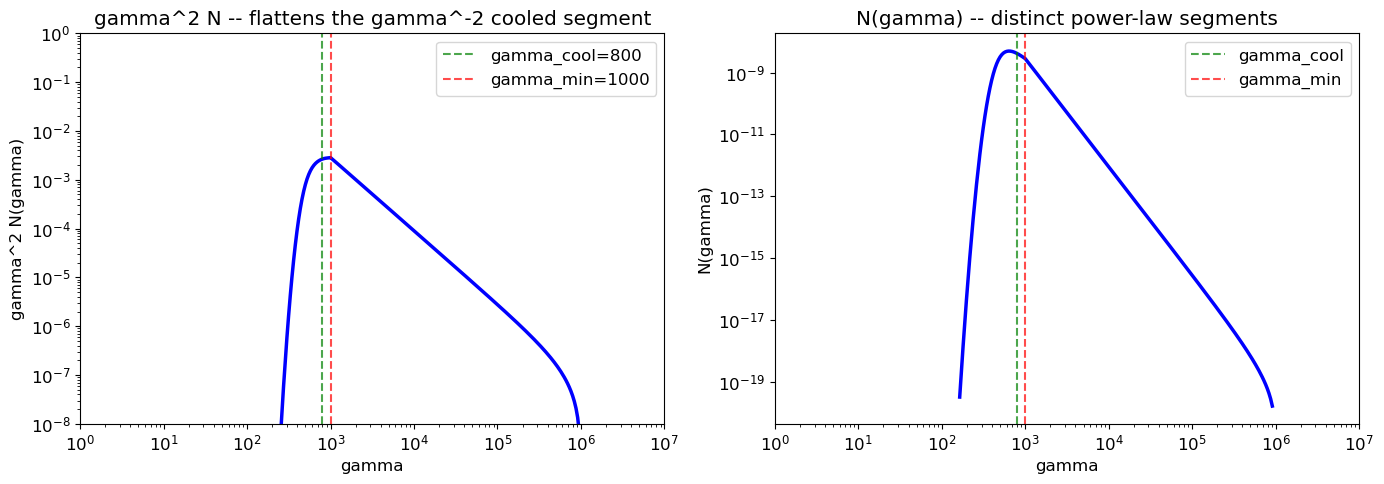

N(gamma) has distinct power-law segments:
  gamma_cool < gamma < gamma_min: N ~ gamma^-2  (cooled electrons)
  gamma_min < gamma < gamma_max:  N ~ gamma^-3.5  (injected + cooled)
  gamma < gamma_cool:             N ~ 0  (no electrons cooled this far yet)

Q(gamma) = gamma^-p is a clean power law. N(gamma) has breaks.
The spectrum is just a kernel convolution of N -- the hard part is solving for N.


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# gamma^2 * N (conventional)
ax1.loglog(gamma_grid, gamma_grid**2 * N_cc, 'b-', lw=2.5)
ax1.axvline(gamma_cool, color='g', ls='--', alpha=0.7, label=f'gamma_cool={gamma_cool:.0f}')
ax1.axvline(gamma_min, color='r', ls='--', alpha=0.7, label=f'gamma_min={gamma_min:.0f}')
ax1.set_xlabel('gamma'); ax1.set_ylabel('gamma^2 N(gamma)')
ax1.set_title('gamma^2 N -- flattens the gamma^-2 cooled segment')
ax1.legend(); ax1.set_xlim(1, 1e7); ax1.set_ylim(1e-8, 1)

# Raw N(gamma)
m = N_cc > 1e-20
ax2.loglog(gamma_grid[m], N_cc[m], 'b-', lw=2.5)
ax2.axvline(gamma_cool, color='g', ls='--', alpha=0.7, label='gamma_cool')
ax2.axvline(gamma_min, color='r', ls='--', alpha=0.7, label='gamma_min')
ax2.set_xlabel('gamma'); ax2.set_ylabel('N(gamma)')
ax2.set_title('N(gamma) -- distinct power-law segments')
ax2.legend(); ax2.set_xlim(1, 1e7)

plt.tight_layout(); plt.show()

print('N(gamma) has distinct power-law segments:')
print(f'  gamma_cool < gamma < gamma_min: N ~ gamma^-2  (cooled electrons)')
print(f'  gamma_min < gamma < gamma_max:  N ~ gamma^-{p+1:.1f}  (injected + cooled)')
print(f'  gamma < gamma_cool:             N ~ 0  (no electrons cooled this far yet)')
print(f'\nQ(gamma) = gamma^-p is a clean power law. N(gamma) has breaks.')
print(f'The spectrum is just a kernel convolution of N -- the hard part is solving for N.')

## What the numerical solution teaches us

Before turning to ML, four lessons from the Chang-Cooper output above:

1. **The solution is piecewise power-law, not a single power law.** Three segments:
   - $\gamma_{\rm cool} < \gamma < \gamma_{\min}$: $\;N \propto \gamma^{-2}$ (cooled regime).
   - $\gamma_{\min} < \gamma < \gamma_{\max}$: $\;N \propto \gamma^{-(p+1)}$ (injected + cooled).
   - $\gamma < \gamma_{\rm cool}$: $\;N \approx 0$ — no electron has had time to cool this far yet.
   The two breaks (at $\gamma_{\rm cool}$ and at $\gamma_{\min}$) are where physics changes character.

2. **Dynamic range.** $N(\gamma)$ spans roughly **10 orders of magnitude** between
   $\gamma_{\rm cool}$ and $\gamma_{\max}$. This is what makes the ML problem hard later: a
   network outputting linear $N$ has to represent $10^{-10}$ accurately at large $\gamma$.

3. **Stiffness.** The cooling time $t_{\rm cool}(\gamma) = 1/(C\gamma)$ varies by a factor
   of $10^{5}$ across the grid — fast at high $\gamma$, slow at low $\gamma$. Chang-Cooper's
   *implicit* time step is what makes this tractable in $\sim 2$ ms.

4. **Why time-integration matters.** The cooling break sits where $\gamma_{\rm cool}(T) = 1/(CT)$ —
   it is a **consequence of the integration window**, not an independent parameter. A
   steady-state expression cannot capture this.

With this picture in hand, we now ask whether a neural network can produce the same
$N(\gamma)$ — and what choice of coordinates and loss makes that question well-posed.


# Now the ML part

## Why log coordinates?

Three reasons to leave linear coordinates behind before training a network:

- $\gamma$ spans $\sim 4$ decades, $N$ spans $\sim 10$ decades, $t$ spans several decades.
  **Linear sampling wastes 99% of points** on the bulk and resolves nothing at the cooling
  break or the high-$\gamma$ tail.
- **A linear-$N$ output cannot represent $10^{-10}$ accurately** through a softplus head —
  the network treats anything below $\sim 10^{-3}$ as numerical zero. This is the failure
  mode the run below will demonstrate.
- **In log coordinates, every power-law segment becomes a straight line** — exactly the
  structure neural networks fit easily.

We define three log variables (used as both names in this discussion and as Python
identifiers if/when we re-implement the PINN in this form):

```
lgamma = log10(γ)        # log Lorentz factor
lt     = log10(t)        # log time
lN     = log10(N)        # log distribution
```

A half-step alternative is to keep $N$ linear and only use `lgamma` on the input — that is
exactly what the implementation below does. Going *all the way* to `lN` cleans up the
dynamic-range failure but introduces a new failure mode (the *self-suppression term* in §
**The equation in transformed coordinates** below). There is no free lunch on this equation.

## The equation in transformed coordinates

Substitute $\gamma = 10^{\rm lgamma}$, $t = 10^{\rm lt}$, $N = 10^{\rm lN}$. The chain rule gives

$$\frac{\partial N}{\partial t} \;=\; \frac{N}{t}\,\frac{\partial \mathrm{lN}}{\partial \mathrm{lt}}, \qquad \frac{\partial N}{\partial \gamma} \;=\; \frac{N}{\gamma}\,\frac{\partial \mathrm{lN}}{\partial \mathrm{lgamma}}.$$

Plugging into the original equation (after expanding $\partial_\gamma(-C\gamma^2 N) = -2C\gamma N - C\gamma^2\,\partial_\gamma N$) and dividing through by $N$:

$$\frac{1}{t}\,\frac{\partial \mathrm{lN}}{\partial \mathrm{lt}} \;-\; C\gamma\,\frac{\partial \mathrm{lN}}{\partial \mathrm{lgamma}} \;-\; 2C\gamma \;=\; \frac{Q(\gamma)}{N}.$$

Multiplying by $t$ to put everything in dimensionless time-derivative form:

$$\boxed{\;\;\frac{\partial \mathrm{lN}}{\partial \mathrm{lt}} \;-\; (Ct\gamma)\,\frac{\partial \mathrm{lN}}{\partial \mathrm{lgamma}} \;-\; 2Ct\gamma \;=\; t\,Q(\gamma)\cdot 10^{-\mathrm{lN}}\;\;}$$

**Reading each term:**

- $\partial_{\mathrm{lt}}\,\mathrm{lN}$ — log-time evolution of log-density: the **slope of $\log N$ vs $\log t$.**
- $(Ct\gamma)\,\partial_{\mathrm{lgamma}}\,\mathrm{lN}$ — cooling-driven *advection in log-energy*. The
  coefficient is $\mathcal{O}(1)$ for $\gamma \sim \gamma_{\rm cool}$, so the equation is
  *not* stiff in log coordinates near the cooling region — it becomes stiff at large $\gamma$.
- $2Ct\gamma$ — comes from $\partial_\gamma(\gamma^2)$; a *constant-in-$\mathrm{lN}$* term that
  pulls $\mathrm{lN}$ down everywhere.
- $t\,Q(\gamma)\cdot 10^{-\mathrm{lN}}$ — **the injection term in log coordinates.**
  This factor of $10^{-\mathrm{lN}}$ is the source of the *asymmetric error landscape* we have
  documented previously: when $\mathrm{lN}$ is **over**estimated, $10^{-\mathrm{lN}}$ is tiny, the
  injection contribution to the residual vanishes, and the optimizer sees zero gradient signal in
  the wrong direction. Going to $\mathrm{lN}$ trades the dynamic-range failure for this one.

**PINN losses in log coordinates.** With network output $\widehat{\mathrm{lN}}_\theta(\mathrm{lgamma}, \mathrm{lt})$:

- **PDE residual at collocation point** $(\mathrm{lgamma}_i, \mathrm{lt}_i)$:
  $$R_i \;=\; \partial_{\mathrm{lt}}\widehat{\mathrm{lN}}_\theta \;-\; (Ct\gamma)\,\partial_{\mathrm{lgamma}}\widehat{\mathrm{lN}}_\theta \;-\; 2Ct\gamma \;-\; t\,Q(\gamma)\cdot 10^{-\widehat{\mathrm{lN}}_\theta},$$
  $$\mathcal{L}_{\rm PDE} \;=\; \frac{1}{N_c}\sum_{i=1}^{N_c} w_i\, R_i^{\,2} \quad\text{($w_i$ from causal weighting, see below).}$$

- **Boundary condition (high $\gamma$):** $N \to 0$ as $\gamma \to \gamma_{\max}$. In log coords this is
  $\widehat{\mathrm{lN}} \to -\infty$, which is unenforceable directly. **Pragmatic enforcement:** require
  $\widehat{\mathrm{lN}}(\mathrm{lgamma}_{\max}, \cdot) \le \mathrm{lN}_{\rm floor}$ (e.g. $-15$) via a one-sided penalty.

- **Initial condition:** $N(\gamma, t = 0) = 0 \Rightarrow \widehat{\mathrm{lN}} \to -\infty$ at $\mathrm{lt} \to -\infty$.
  Two practical choices:
  1. *Hard ansatz* $\widehat{\mathrm{lN}} = \mathrm{lN}_{\rm floor} + (\mathrm{lt} - \mathrm{lt}_0)\cdot \mathrm{softplus}(\mathrm{net}(\mathrm{lgamma}, \mathrm{lt}))$
     for a small starting time $t_0 > 0$ — removes the IC loss entirely.
  2. *Soft penalty* at $\mathrm{lt} = \mathrm{lt}_0$: $\big(\widehat{\mathrm{lN}} - \mathrm{lN}_{\rm floor}\big)_+^{\,2}$.

- **Total loss:** $\mathcal{L} = \mathcal{L}_{\rm PDE} + \lambda_{BC}\,\mathcal{L}_{BC}\;\big[+\,\lambda_{IC}\,\mathcal{L}_{IC}\big].$

> Going to $(\mathrm{lgamma}, \mathrm{lt}, \mathrm{lN})$ makes power-laws straight, the dynamic
> range manageable, and the boundary at $\gamma_{\max}$ tractable — but the source term acquires
> the $10^{-\mathrm{lN}}$ factor that creates a one-sided gradient signal. **The implementation
> below uses linear $N$ on input $\mathrm{lgamma}$ — half-log — and demonstrates the dynamic-range
> failure mode that motivates this section.**

## Causality: what it is and why we enforce it

The PDE is *causal* — the solution at $t_2 > t_1$ is determined by the solution at $t_1$, not
the other way around. A naive PINN ignores this and minimizes the residual at every $(\gamma, t)$
point simultaneously. The optimizer takes the path of least resistance: find a smooth, low-residual
*late-time* profile (often the steady-state shape) without ever propagating from $N(\gamma, t = 0) = 0$.
**Net result: low PDE loss, wrong physics.**

The fix (Wang, Sankaran, Perdikaris, *CMAME* 2024) is to weight residuals by the *cumulative residual at all earlier times*:

$$w(t_k) \;=\; \exp\!\left(-\,\varepsilon \sum_{j<k} R^2(t_j)\right).$$

In words:
- Sort residual points by $t$ (or $\mathrm{lt}$).
- Each point's weight is suppressed by how badly the residuals are doing at *earlier* times.
- Initially, only the earliest few times contribute meaningfully; as those residuals shrink,
  the weights at slightly later times are released.
- **Net effect:** forced forward-in-time learning. The PINN can only "earn" credit at $t_k$
  once it has satisfied the PDE at $t < t_k$.

We use $\varepsilon = 0.1$ (a more aggressive $\varepsilon = 1$ crushed all but a handful of
early-$\tau$ points before any could be satisfied — different failure mode). The diagnostic
plots produced by the comparison cell at the end of the notebook (mean weight trajectory,
final $w$ vs $\tau$ scatter) are the evidence that the causal mechanism is functioning.

Without causality, the network converges to a $t$-independent, steady-state-like profile
that is decoupled from the initial condition — a vivid concrete example of "low loss, wrong
physics."

## Collocation sampling: random, not grid

**What we do.** Each gradient step we draw

- $\sim 2{,}000$ collocation points $(\mathrm{lgamma}, \mathrm{lt})$ **uniformly at random**
  over the rectangle $[\mathrm{lgamma}_{\min}, \mathrm{lgamma}_{\max}] \times [\mathrm{lt}_0, \mathrm{lt}_{\max}]$,
- $500$ BC points: random $\mathrm{lt}$ at each of the two $\mathrm{lgamma}$ boundaries,
- a **fresh sample at every gradient step** — no fixed mesh.

**Why uniform random in $(\mathrm{lgamma}, \mathrm{lt})$ rather than a fixed grid:**

1. **A grid lets the network memorize.** With a fixed $100\times 100$ mesh, the optimizer
   can drive the residual to $\sim 0$ at exactly those $10{,}000$ points while leaving it
   large everywhere else — the PINN "passes the test" without learning the continuum solution.
2. **Random sampling = effectively infinite data.** Re-drawing each epoch forces the network
   to satisfy the PDE *as a function*, not as a discrete tabulation. Generalization on the
   continuum is exactly what we want.
3. **Uniform-in-log already concentrates resolution where physics changes.** Sampling uniform
   in $\mathrm{lgamma}$ gives equal density per *decade* of $\gamma$, automatically resolving the
   cooling break, the injection range, and the high-$\gamma$ tail — without any manual mesh-grading.
4. **It composes with causal weighting.** The Wang weights need points spread across $\mathrm{lt}$;
   uniform random sampling delivers that statistic naturally each step.

**What we are *not* doing yet** (offered as the natural next steps):
- **Residual-Adaptive Resampling (RAR / R3, Daw 2023).** Score a candidate pool by $R^2$ and
  over-represent the high-residual points — typically the cooling-break neighborhood. A
  follow-up implementation lives in `adaptive_pinn_train.py` but is not wired into this
  notebook for tomorrow's talk.
- **Time-stratified pools.** Equal points per $\mathrm{lt}$-bin, to reinforce causal training at
  early times.

> With the equation rewritten in $(\mathrm{lgamma}, \mathrm{lt}, \mathrm{lN})$, the PINN losses
> defined, the causal weighting motivated, and the sampling strategy chosen, we now turn to the
> actual implementation.


In [5]:
class PINN(nn.Module):
    def __init__(self, n_hidden=128, n_layers=5, n_fourier=32, sigma_ff=3.0):
        super().__init__()
        # Fixed random Fourier feature matrix (buffer -- not a trainable parameter)
        self.register_buffer('B_ff', torch.randn(1, n_fourier) * sigma_ff)
        in_dim = 2 * n_fourier + 1   # [sin(2pi B sigma), cos(2pi B sigma), tau]
        layers = [nn.Linear(in_dim, n_hidden), nn.Tanh()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(n_hidden, n_hidden), nn.Tanh()]
        layers.append(nn.Linear(n_hidden, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, sigma, tau):
        proj = 2 * np.pi * sigma @ self.B_ff        # (N, n_fourier)
        ff   = torch.cat([torch.sin(proj), torch.cos(proj)], dim=1)
        x    = torch.cat([ff, tau], dim=1)
        raw  = self.net(x)
        # Hard IC: n(sigma, tau=0) = 0 exactly. Softplus for positivity.
        return tau * torch.nn.functional.softplus(raw)

model = PINN().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f'PINN: 5x128, tanh, RFF(32, sigma_ff=3), hard IC ansatz')
print(f'      {n_params:,} params, {next(model.parameters()).dtype}')


PINN: 5x128, tanh, RFF(32, sigma_ff=3), hard IC ansatz
      74,625 params, torch.float64


### Loss function (causal PDE + BC, no IC term)

1. Sample $(\sigma, \tau) \in [\log_{10}\chi,\ \log_{10} y_{\max}] \times [0, 1]$.
2. Forward pass, autograd: $n_\sigma$, $n_\tau$; chain rule $n_y = n_\sigma / (y \ln 10)$.
3. Residual $R = n_\tau - (y^2/\chi)\, n_y - (2y/\chi)\, n - \tilde Q(y)$.
4. **Causal weighting**: sort by $\tau$, $w_i = \exp(-\epsilon \sum_{j<i} R_j^2)$, with $\epsilon = 0.1$ (a more aggressive $\epsilon=1$ crushed all but a handful of early-$\tau$ points).
5. $L = \mathrm{mean}(w_i R_i^2) + \lambda_{BC}\, L_{BC}$. No IC -- handled by the ansatz.

In [6]:
# Burgess dimensionless coordinates
y_max      = gamma_max / gamma_min              # = 1000
SIGMA_MIN  = np.log10(chi)                       # ~ -0.097 (cooling front at y=chi)
SIGMA_MAX  = np.log10(y_max)                     # = 3.0    (high-gamma cutoff)
TAU_MAX    = 1.0                                 # tau = 1 at t = T_emission
EPSILON_CAUSAL = 0.1                             # causal strength (eps=1 crushed all but a handful of early-tau points)

# Q_tilde(y) = y^-p / Z_bar,  integral Q_tilde * y dy = 1 over [1, y_max].
_Z_BAR = (1.0 - y_max**(2 - p)) / (p - 2)

def injection_source(y):
    Q = torch.zeros_like(y)
    mask = (y >= 1.0) & (y <= y_max)
    Q[mask] = y[mask] ** (-p) / _Z_BAR
    return Q

def compute_pinn_loss(model, n_colloc=2000, n_bc=500):
    sigma = SIGMA_MIN + (SIGMA_MAX - SIGMA_MIN) * torch.rand(n_colloc, 1, device=device)
    tau   = TAU_MAX   * torch.rand(n_colloc, 1, device=device)
    sigma.requires_grad_(True); tau.requires_grad_(True)

    n = model(sigma, tau)
    y = 10.0 ** sigma

    dn_dsigma = torch.autograd.grad(n, sigma, grad_outputs=torch.ones_like(n), create_graph=True)[0]
    dn_dy     = dn_dsigma / (y * np.log(10))
    dn_dtau   = torch.autograd.grad(n, tau,   grad_outputs=torch.ones_like(n), create_graph=True)[0]

    Q_tilde  = injection_source(y)
    residual = dn_dtau - (y**2 / chi) * dn_dy - (2 * y / chi) * n - Q_tilde

    # Causal weighting: sort by tau, weight by exp(-eps * cumulative prior residual^2)
    sorted_idx = torch.argsort(tau.squeeze())
    R_sorted   = residual.squeeze()[sorted_idx]
    with torch.no_grad():
        cumsum_R2    = torch.cumsum(R_sorted ** 2, dim=0)
        cumsum_prior = torch.cat([torch.zeros(1, device=R_sorted.device), cumsum_R2[:-1]])
        weights      = torch.exp(-EPSILON_CAUSAL * cumsum_prior)
    L_pde  = (weights * R_sorted ** 2).mean()
    mean_w = weights.mean().item()

    # BC: n = 0 at sigma = log10(chi) and sigma = log10(y_max), for tau in [0, TAU_MAX]
    tau_bc = TAU_MAX * torch.rand(n_bc, 1, device=device)
    L_bc = (model(torch.full((n_bc,1), SIGMA_MIN, device=device), tau_bc)**2).mean() + \
           (model(torch.full((n_bc,1), SIGMA_MAX, device=device), tau_bc)**2).mean()

    return L_pde, L_bc, mean_w

L_pde, L_bc, mean_w = compute_pinn_loss(model, n_colloc=200)
print(f'Initial: L_pde={L_pde.item():.3e}  L_bc={L_bc.item():.3e}  mean_causal_weight={mean_w:.3e}')
print(f'Domain:  sigma in [{SIGMA_MIN:.3f}, {SIGMA_MAX:.3f}]  tau in [0, {TAU_MAX}]  epsilon={EPSILON_CAUSAL}')

Initial: L_pde=1.604e-01  L_bc=3.101e-01  mean_causal_weight=2.006e-02
Domain:  sigma in [-0.097, 3.000]  tau in [0, 1.0]  epsilon=0.1


### Training: 10000 epochs, Adam + cosine annealing

Fresh random collocation each epoch. $\lambda_{BC} = 10$. No IC term.
Cosine anneal LR from $10^{-3}$ down to $10^{-5}$ over the full run.


In [7]:
N_EPOCHS = 3000; LAMBDA_BC = 10.0
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=1e-5)
history = {'pde': [], 'bc': [], 'mean_w': [], 'total': []}

print(f'Training PINN for {N_EPOCHS} epochs (Burgess dim, RFF, hard IC, causal weighting)...\n')
t0 = time.time()
for epoch in range(N_EPOCHS):
    optimizer.zero_grad()
    L_pde, L_bc, mean_w = compute_pinn_loss(model)
    loss = L_pde + LAMBDA_BC * L_bc
    loss.backward(); optimizer.step(); scheduler.step()
    history['pde'].append(L_pde.item())
    history['bc'].append(L_bc.item())
    history['mean_w'].append(mean_w)
    history['total'].append(loss.item())
    if epoch % 200 == 0 or epoch == N_EPOCHS - 1:
        print(f'  Epoch {epoch:5d}/{N_EPOCHS}  |  L_pde={L_pde.item():.3e}  '
              f'L_bc={L_bc.item():.3e}  mean_w={mean_w:.3e}  lr={scheduler.get_last_lr()[0]:.1e}', flush=True)

t_train = time.time() - t0
print(f'\nTime: {t_train:.0f}s (Chang-Cooper: {t_cc*1000:.0f}ms, {t_train/t_cc:.0f}x slower)')

Training PINN for 3000 epochs (Burgess dim, RFF, hard IC, causal weighting)...

  Epoch     0/3000  |  L_pde=8.702e-03  L_bc=3.080e-01  mean_w=5.593e-03  lr=1.0e-03
  Epoch   200/3000  |  L_pde=4.499e-03  L_bc=1.539e-08  mean_w=4.747e-01  lr=9.9e-04
  Epoch   400/3000  |  L_pde=4.120e-03  L_bc=2.640e-09  mean_w=4.924e-01  lr=9.6e-04
  Epoch   600/3000  |  L_pde=4.013e-03  L_bc=1.195e-09  mean_w=4.751e-01  lr=9.1e-04
  Epoch   800/3000  |  L_pde=3.935e-03  L_bc=7.167e-10  mean_w=4.874e-01  lr=8.4e-04
  Epoch  1000/3000  |  L_pde=3.628e-03  L_bc=4.899e-10  mean_w=5.576e-01  lr=7.5e-04
  Epoch  1200/3000  |  L_pde=4.060e-03  L_bc=3.889e-10  mean_w=5.179e-01  lr=6.6e-04
  Epoch  1400/3000  |  L_pde=3.871e-03  L_bc=3.207e-10  mean_w=5.697e-01  lr=5.6e-04
  Epoch  1600/3000  |  L_pde=3.987e-03  L_bc=2.811e-10  mean_w=4.676e-01  lr=4.5e-04
  Epoch  1800/3000  |  L_pde=3.946e-03  L_bc=2.346e-10  mean_w=5.139e-01  lr=3.5e-04
  Epoch  2000/3000  |  L_pde=3.708e-03  L_bc=2.204e-10  mean_w=5.489e-

## Part 3: Comparison in dimensionless coordinates

Convert CC's output to the PINN scaling and compare in $(y, n)$ space. Also plot the final
causal-weight distribution over $\tau$: if the PINN has learned the whole time range, weights
should be $\sim 1$ everywhere; if it has only learned early $\tau$, weights will drop at late $\tau$.

$$n_{\rm cc}(y) = \frac{\gamma_{\min}^2}{T_{\rm emission}}\, N_{\rm cc}(\gamma_{\min}\, y)\bigg|_{\tau=1}$$


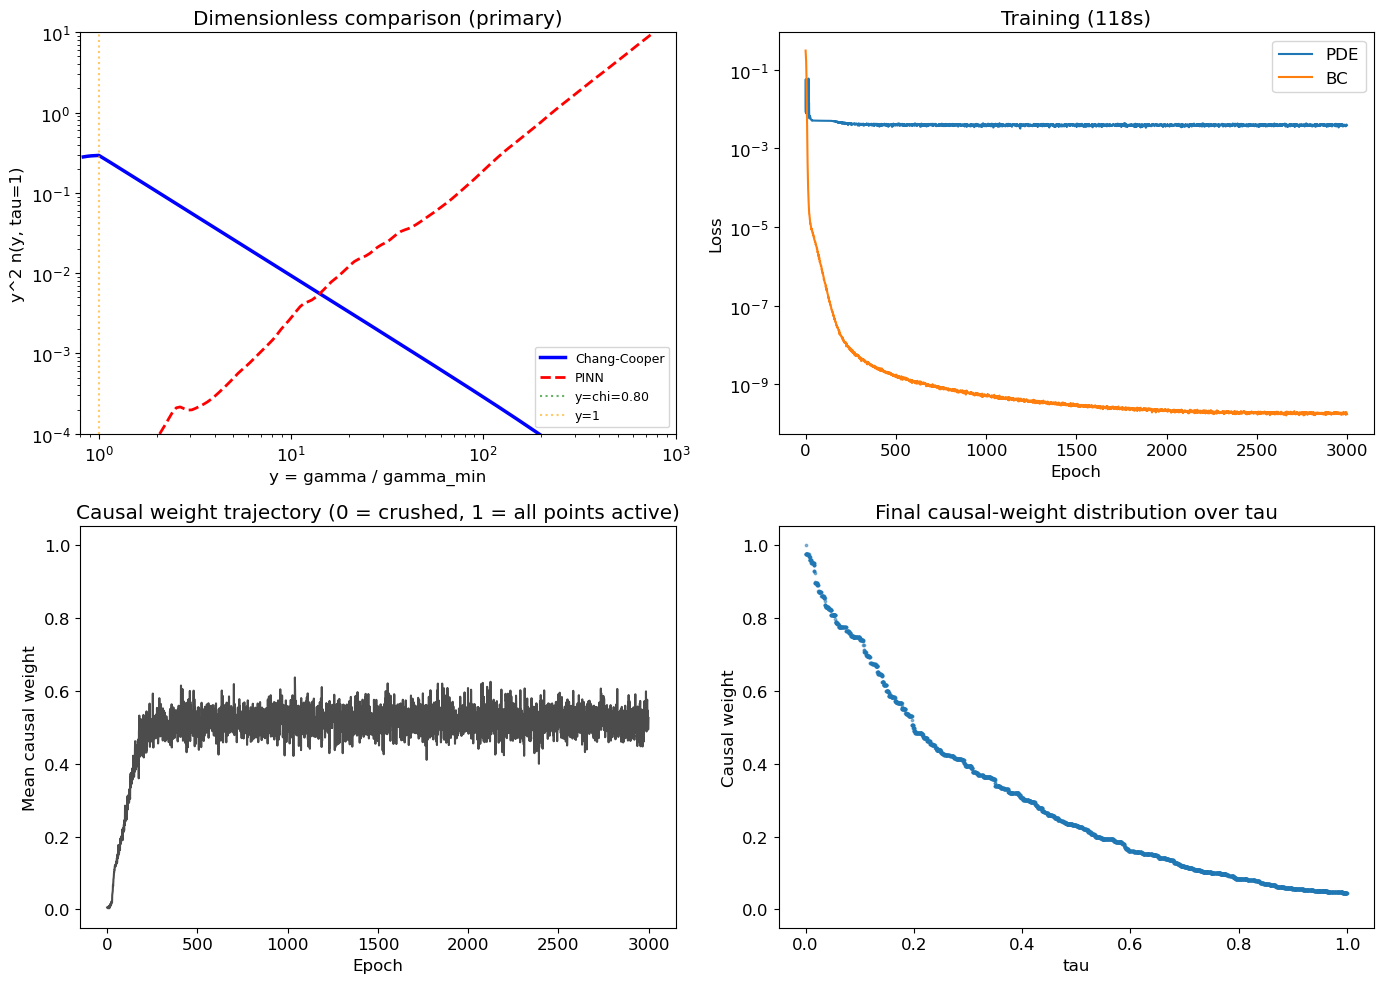

Mean error: 2.43 dex (1 dex = factor 10)
Max error:  5.25 dex
Final PDE loss: 3.862e-03
Final BC loss:  1.741e-10
Final mean weight: 5.250e-01


In [8]:
model.eval()
with torch.no_grad():
    # Dimensionless grid
    y_grid  = gamma_grid / gamma_min
    in_dom  = (y_grid >= chi) & (y_grid <= y_max)
    y_eval  = y_grid[in_dom]
    sigma_eval = torch.tensor(np.log10(y_eval), device=device).reshape(-1, 1)
    tau_eval   = torch.full_like(sigma_eval, TAU_MAX)
    n_pinn = model(sigma_eval, tau_eval).cpu().numpy().flatten()

# Convert CC to PINN's dimensionless scaling
n_cc = (gamma_min**2 / T_emission) * N_cc[in_dom]

# Diagnostic batch for the final causal-weight distribution over tau
# Need two autograd.grad calls on the same output -> keep the graph between calls with retain_graph=True.
sigma_d = SIGMA_MIN + (SIGMA_MAX - SIGMA_MIN) * torch.rand(4000, 1, device=device)
tau_d   = TAU_MAX   * torch.rand(4000, 1, device=device)
sigma_d.requires_grad_(True); tau_d.requires_grad_(True)
n_d = model(sigma_d, tau_d); y_d = 10.0 ** sigma_d
dn_ds   = torch.autograd.grad(n_d, sigma_d, grad_outputs=torch.ones_like(n_d), retain_graph=True)[0]
dn_dy_d = dn_ds / (y_d * np.log(10))
dn_dt_d = torch.autograd.grad(n_d, tau_d,   grad_outputs=torch.ones_like(n_d))[0]
Q_d = injection_source(y_d)
R_d = dn_dt_d - (y_d**2/chi)*dn_dy_d - (2*y_d/chi)*n_d - Q_d
sidx    = torch.argsort(tau_d.squeeze())
R_s     = R_d.squeeze()[sidx].detach()
t_s     = tau_d.squeeze()[sidx].detach()
cum     = torch.cumsum(R_s**2, dim=0)
prior   = torch.cat([torch.zeros(1, device=cum.device), cum[:-1]])
w_final = torch.exp(-EPSILON_CAUSAL * prior).cpu().numpy()
t_plot  = t_s.cpu().numpy()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (1) Primary: dimensionless y^2 * n vs y
ax = axes[0, 0]
ax.loglog(y_eval, y_eval**2 * n_cc, 'b-',  lw=2.5, label='Chang-Cooper')
ax.loglog(y_eval, y_eval**2 * np.maximum(n_pinn, 1e-30), 'r--', lw=2, label='PINN')
ax.axvline(chi, color='g',      ls=':', alpha=0.6, label=f'y=chi={chi:.2f}')
ax.axvline(1.0, color='orange', ls=':', alpha=0.6, label='y=1')
ax.set_xlabel('y = gamma / gamma_min'); ax.set_ylabel('y^2 n(y, tau=1)')
ax.set_title('Dimensionless comparison (primary)'); ax.legend(fontsize=9)
ax.set_xlim(chi, y_max); ax.set_ylim(1e-4, 10)

# (2) Training curves
ax = axes[0, 1]
ax.semilogy(history['pde'], label='PDE'); ax.semilogy(history['bc'], label='BC')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss'); ax.set_title(f'Training ({t_train:.0f}s)'); ax.legend()

# (3) Causal weight mean over training
ax = axes[1, 0]
ax.plot(history['mean_w'], 'k-', alpha=0.7)
ax.set_xlabel('Epoch'); ax.set_ylabel('Mean causal weight')
ax.set_title('Causal weight trajectory (0 = crushed, 1 = all points active)')
ax.set_ylim(-0.05, 1.05)

# (4) Final causal-weight distribution over tau
ax = axes[1, 1]
ax.scatter(t_plot, w_final, s=3, alpha=0.5)
ax.set_xlabel('tau'); ax.set_ylabel('Causal weight')
ax.set_title('Final causal-weight distribution over tau')
ax.set_ylim(-0.05, 1.05)

plt.tight_layout(); plt.show()

mask_valid = (n_cc > 1e-10) & (n_pinn > 1e-10)
if mask_valid.sum() > 0:
    log_ratio = np.abs(np.log10(n_pinn[mask_valid]) - np.log10(n_cc[mask_valid]))
    print(f'Mean error: {log_ratio.mean():.2f} dex (1 dex = factor 10)')
    print(f'Max error:  {log_ratio.max():.2f} dex')
    print(f'Final PDE loss: {history["pde"][-1]:.3e}')
    print(f'Final BC loss:  {history["bc"][-1]:.3e}')
    print(f'Final mean weight: {history["mean_w"][-1]:.3e}')
else:
    print('PINN collapsed to trivial solution.')

### Interpretation

The three upgrades target the three remaining failure modes from the vanilla run:

1. **RFF on $\sigma$** -> spectral bias (can the PINN see the cooling break?)
2. **Hard IC ansatz** -> IC competing loss (one fewer term dragging the optimizer)
3. **Causal weighting** -> acausal training (time-correct learning order)

What to look for in the plots:
- **Top-left (dim comparison):** does the PINN track CC from $y=\chi$ up through $y=1$ (cooled region,
  $\gamma^{-2}$ segment) and then along $y^{-(p+1)}$ above $y=1$? Or does it miss the break?
- **Top-right (training curves):** PDE loss should keep dropping. BC loss should also drop.
- **Bottom-left (mean weight over time):** should start near 0 (aggressive causal damping) and
  climb toward 1 as the PINN satisfies the PDE at early $\tau$ first.
- **Bottom-right (final weight vs $\tau$):** if weights are uniform $\sim 1$, the PINN has learned
  across all time. If weights drop at large $\tau$, only early $\tau$ is being satisfied.

If mean error is still $\gtrsim 0.5$ dex, the remaining gap is likely equation-specific
(the asymmetric-error-landscape issue -- see April 2 diagnosis), not a missing PINN trick.
In that case the next step is supervised anchoring (a few Chang-Cooper data points added to the
loss), which is outside this notebook's scope.


## Does the sampling strategy matter?

Three sampling strategies, **same architecture / loss / training schedule** — only the collocation strategy varies:

| | Strategy | Where the points come from |
|---|---|---|
| (i) | **Uniform random** | 2,000 fresh points $(\sigma, \tau)$ each epoch (the baseline above) |
| (ii) | **Fixed $50\times 40$ grid** | the same 2,000 grid-cell-centered points every epoch |
| (iii) | **RAR + time-stratified** | 6,000-point pool stratified in $\tau$, top 40% by $R^2$ + uniform fill |

Trained scripts: `grid_pinn_train.py` and `adaptive_pinn_train.py`. Results in `grid_pinn_results.npz` and `adaptive_pinn_results.npz`.

Spoiler: **all three land within 0.05 dex of each other** at $\sim 2.4$ dex error. The failure floor is *equation-specific*, not sampling-specific.

The plot below also reports the grid-PINN's residual on its training mesh vs. on fresh random points — a diagnostic for the "fixed grid lets the network memorize" concern raised in the ML-intro section. The off-grid residual is only $\sim 1.6\times$ the on-grid residual, so memorization is real but mild — not the dominant failure here.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Adaptive PINN (RAR + time-stratified) results
adaptive   = np.load('adaptive_pinn_results.npz')
y_a        = adaptive['y_eval']
n_pinn_a   = adaptive['n_pinn']
hist_pde_a = adaptive['hist_pde']
hist_mw_a  = adaptive['hist_mw']
mean_dex_a = float(adaptive['mean_dex'])
max_dex_a  = float(adaptive['max_dex'])

# Grid PINN results (fixed 50×40 mesh)
grid_res    = np.load('grid_pinn_results.npz')
y_g         = grid_res['y_eval']
n_pinn_g    = grid_res['n_pinn']
hist_pde_g  = grid_res['hist_pde']
hist_mw_g   = grid_res['hist_mw']
mean_dex_g  = float(grid_res['mean_dex'])
max_dex_g   = float(grid_res['max_dex'])
R2_on_grid  = grid_res['R2_on_grid']
R2_off_grid = grid_res['R2_off_grid']

# Baseline numbers from cell 14 (uniform-random PINN)
mask_b     = (n_cc > 1e-10) & (n_pinn > 1e-10)
mean_dex_b = float(np.abs(np.log10(n_pinn[mask_b]) - np.log10(n_cc[mask_b])).mean())
max_dex_b  = float(np.abs(np.log10(n_pinn[mask_b]) - np.log10(n_cc[mask_b])).max())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# (1) y² · n: CC + 3 PINN sampling strategies
ax = axes[0]
ax.loglog(y_eval, y_eval**2 * n_cc, 'b-', lw=2.5, label='Chang-Cooper')
ax.loglog(y_eval, y_eval**2 * np.maximum(n_pinn,   1e-30), 'r--', lw=2,
          label=f'(i) uniform random   {mean_dex_b:.2f} dex')
ax.loglog(y_g,    y_g**2     * np.maximum(n_pinn_g, 1e-30), 'm-.', lw=2,
          label=f'(ii) fixed 50×40 grid {mean_dex_g:.2f} dex')
ax.loglog(y_a,    y_a**2     * np.maximum(n_pinn_a, 1e-30), 'g:',  lw=2,
          label=f'(iii) RAR + stratified {mean_dex_a:.2f} dex')
ax.axvline(chi, color='k', ls=':', alpha=0.4)
ax.axvline(1.0, color='k', ls=':', alpha=0.4)
ax.set_xlabel('y = γ / γ_min'); ax.set_ylabel('y² · n(y, τ=1)')
ax.set_title('Three sampling strategies, same answer')
ax.legend(fontsize=9, loc='lower left'); ax.set_xlim(chi, y_max); ax.set_ylim(1e-4, 10)

# (2) Memorization diagnostic for the GRID PINN: residual on its training mesh vs off-mesh
ax = axes[1]
bins = np.logspace(np.log10(min(R2_on_grid.min(), R2_off_grid.min()) + 1e-30),
                   np.log10(max(R2_on_grid.max(), R2_off_grid.max())), 40)
ax.hist(R2_on_grid,  bins=bins, alpha=0.6, label=f'on training mesh   ⟨R²⟩={R2_on_grid.mean():.2e}',  color='m')
ax.hist(R2_off_grid, bins=bins, alpha=0.6, label=f'off-mesh (random) ⟨R²⟩={R2_off_grid.mean():.2e}', color='gray')
ax.set_xscale('log')
ax.set_xlabel('Residual² at evaluation point')
ax.set_ylabel('Count')
ax.set_title(f'Grid-PINN residual on vs off mesh ({R2_off_grid.mean()/R2_on_grid.mean():.1f}× higher off-mesh)')
ax.legend(fontsize=9)

# (3) Mean causal weight trajectory (all three)
ax = axes[2]
ax.plot(history['mean_w'], 'r-', alpha=0.7, label='(i) uniform random')
ax.plot(hist_mw_g,         'm-', alpha=0.7, label='(ii) fixed grid')
ax.plot(hist_mw_a,         'g-', alpha=0.7, label='(iii) RAR + stratified')
ax.set_xlabel('Epoch'); ax.set_ylabel('Mean causal weight')
ax.set_title('Causal-weight trajectories')
ax.set_ylim(-0.05, 1.05); ax.legend(fontsize=9)

plt.tight_layout(); plt.show()

print(f'(i)  Uniform random        : mean = {mean_dex_b:.2f} dex,  max = {max_dex_b:.2f} dex')
print(f'(ii) Fixed 50×40 grid     : mean = {mean_dex_g:.2f} dex,  max = {max_dex_g:.2f} dex')
print(f'(iii) RAR + time-stratified: mean = {mean_dex_a:.2f} dex,  max = {max_dex_a:.2f} dex')
print()
print(f'Grid-PINN residual: ⟨R²⟩ on mesh = {R2_on_grid.mean():.2e}, off mesh = {R2_off_grid.mean():.2e}')
print(f'                    -> off/on ratio {R2_off_grid.mean()/R2_on_grid.mean():.1f}x  (mild memorization)')
print()
print('All three sampling strategies hit the SAME ~2.4 dex floor.')
print('Sampling cannot escape an equation-specific failure mode.')

## What if we go all the way to log–log–log?

The implementation above kept $N$ linear and only logged the input. The "Now the ML part" section above derived the equation in fully-log coordinates $(\mathrm{lgamma}, \mathrm{lt}, \mathrm{lN})$:

$$\frac{\partial \mathrm{lN}}{\partial \mathrm{lt}} - (Ct\gamma)\,\frac{\partial \mathrm{lN}}{\partial \mathrm{lgamma}} - 2Ct\gamma = t\,Q(\gamma)\cdot 10^{-\mathrm{lN}}.$$

The script `lN_pinn_train.py` re-implements the PINN in exactly this form:

- Network output: $\widehat{\mathrm{lN}}_\theta = -A\cdot \mathrm{softplus}(\mathrm{net})$, bounded above by $0$ (since $N \le 1$ in our normalization), unbounded below.
- Soft IC at $\mathrm{lt} = \mathrm{lt}_0$: penalty if $\widehat{\mathrm{lN}} > \mathrm{lN}_{\rm floor} = -18$.
- Soft BCs at $\gamma_{\rm low}$ and $\gamma_{\rm max}$: same one-sided floor penalty.
- Causal weighting on $\mathrm{lt}$ with $\varepsilon = 0.1$.

**Predicted failure mode.** The injection term has acquired a $10^{-\mathrm{lN}}$ factor. If the optimizer ever lets $\mathrm{lN}$ drift *upward* (over-estimate $N$), then $10^{-\mathrm{lN}}$ shrinks, the injection contribution to the residual disappears, and the PDE collapses to its advection-only form

$$\partial_{\mathrm{lt}}\mathrm{lN} - (Ct\gamma)\,\partial_{\mathrm{lgamma}}\mathrm{lN} - 2Ct\gamma = 0,$$

whose steady-state has the slope $\partial_{\mathrm{lgamma}}\mathrm{lN} = -2$ — the *cooling attractor*. So the diagnostic to watch is the slope of the network output: a flat $-2$ everywhere is the failure signature, even if the PDE residual is tiny. **Lower loss in the wrong-attractor direction is exactly the asymmetric-error-landscape pathology.**

The cell below loads `lN_pinn_results.npz` and plots:
1. $N(\gamma)$ from Chang-Cooper, the linear-$N$ baseline PINN, and the $\mathrm{lN}$-PINN, on the same axes.
2. The empirical slope $\partial_{\mathrm{lgamma}}\widehat{\mathrm{lN}}$ from the trained $\mathrm{lN}$ network — if it's flat at $-2$ in the bulk, the diagnosis is confirmed.

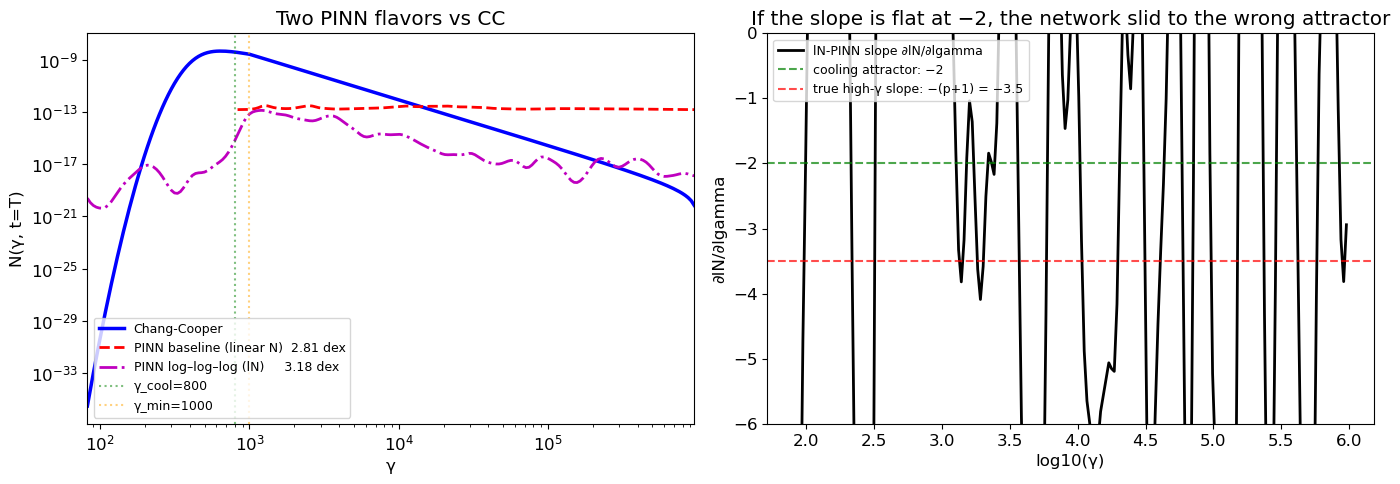

Baseline PINN (linear N):        mean error = 2.81 dex
lN-PINN     (log–log–log):       mean error = 3.18 dex,  max = 9.10 dex
Median bulk slope ∂lN/∂lgamma:   -1.91   (−2 = cooling attractor; −3.5 = true high-γ)


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Load lN-PINN results from the offline run
ln_res     = np.load('lN_pinn_results.npz')
gamma_lN   = ln_res['gamma_eval']         # γ grid in physical units
N_cc_lN    = ln_res['N_cc_eval']           # CC values on this grid (physical N)
N_pinn_lN  = ln_res['N_pinn']              # lN-PINN values (physical N = 10^lN)
slope_diag = ln_res['slope_diag']          # ∂lN/∂lgamma at t=T_emission
mean_dex_l = float(ln_res['mean_dex'])
max_dex_l  = float(ln_res['max_dex'])

# Re-derive baseline PINN values on the same physical γ grid via interpolation.
# (Baseline ran in dimensionless (y, n); convert back to N(γ).)
gamma_b = y_eval * gamma_min                  # y -> γ
N_cc_b  = n_cc * (T_emission / gamma_min**2)  # invert the dimensionless rescaling
N_pinn_b = n_pinn * (T_emission / gamma_min**2)

mask_b = (N_cc_b > 1e-25) & (N_pinn_b > 1e-25)
mean_dex_b = float(np.abs(np.log10(N_pinn_b[mask_b]) - np.log10(N_cc_b[mask_b])).mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (1) N(γ) on a single physical axis: CC, baseline (linear-N), lN-PINN
ax = axes[0]
ax.loglog(gamma_lN, N_cc_lN,  'b-',  lw=2.5, label='Chang-Cooper')
ax.loglog(gamma_b,  np.maximum(N_pinn_b,  1e-30), 'r--', lw=2,
          label=f'PINN baseline (linear N)  {mean_dex_b:.2f} dex')
ax.loglog(gamma_lN, np.maximum(N_pinn_lN, 1e-30), 'm-.', lw=2,
          label=f'PINN log–log–log (lN)     {mean_dex_l:.2f} dex')
ax.axvline(gamma_cool, color='g', ls=':', alpha=0.5, label=f'γ_cool={gamma_cool:.0f}')
ax.axvline(gamma_min,  color='orange', ls=':', alpha=0.5, label=f'γ_min={gamma_min:.0f}')
ax.set_xlabel('γ'); ax.set_ylabel('N(γ, t=T)')
ax.set_title('Two PINN flavors vs CC')
ax.legend(fontsize=9, loc='lower left')
ax.set_xlim(gamma_lN.min(), gamma_lN.max())

# (2) Slope diagnostic: ∂lN/∂lgamma should be flat at −2 if collapsed to cooling attractor
ax = axes[1]
ax.plot(np.log10(gamma_lN), slope_diag, 'k-', lw=2, label='lN-PINN slope ∂lN/∂lgamma')
ax.axhline(-2.0,    color='g', ls='--', alpha=0.7, label='cooling attractor: −2')
ax.axhline(-(2.5+1), color='r', ls='--', alpha=0.7, label='true high-γ slope: −(p+1) = −3.5')
ax.set_xlabel('log10(γ)'); ax.set_ylabel('∂lN/∂lgamma')
ax.set_title('If the slope is flat at −2, the network slid to the wrong attractor')
ax.legend(fontsize=9)
ax.set_ylim(-6, 0)

plt.tight_layout(); plt.show()

# Median slope in the bulk: cleanest single-number summary
bulk_mask = (gamma_lN > gamma_cool) & (gamma_lN < gamma_max / 5)
median_bulk_slope = float(np.median(slope_diag[bulk_mask]))

print(f'Baseline PINN (linear N):        mean error = {mean_dex_b:.2f} dex')
print(f'lN-PINN     (log–log–log):       mean error = {mean_dex_l:.2f} dex,  max = {max_dex_l:.2f} dex')
print(f'Median bulk slope ∂lN/∂lgamma:   {median_bulk_slope:+.2f}   (−2 = cooling attractor; −3.5 = true high-γ)')